In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
ROOT = Path.cwd().parents[1]
DATA_PROCESSED = ROOT / "data_processed"
OUTPUTS = ROOT / "outputs"

in_path = DATA_PROCESSED / "07_analysis_dataset.parquet"
df = pd.read_parquet(in_path)
df["pressure_swing"].describe()

count    39264.000000
mean         0.015723
std          0.020128
min          0.000000
25%          0.001667
50%          0.008737
75%          0.022205
max          0.282146
Name: pressure_swing, dtype: float64

In [15]:
pressure_threshold = df["pressure_swing"].quantile(0.90)
print("Top 10% pressure threshold:", round(pressure_threshold, 6))

Top 10% pressure threshold: 0.040417


In [ ]:
df_long_p1 = df.copy()
df_long_p1["player"] = df_long_p1["player1"]
df_long_p1["won_point"] = df_long_p1["p1_won_point"]

df_long_p2 = df.copy()
df_long_p2["player"] = df_long_p2["player2"]
df_long_p2["won_point"] = 1 - df_long_p2["p1_won_point"]

df_long = pd.concat([df_long_p1, df_long_p2], ignore_index=True)

df_long["high_pressure"] = df_long["pressure_swing"] >= pressure_threshold

df_long.head()

In [16]:
print("Number of original points:", len(df))
print("Number of player-point rows:", len(df_long))
print("Expected double:", len(df) * 2)
print("High-pressure share:", df_long["high_pressure"].mean())

Number of original points: 39264
Number of player-point rows: 78528
Expected double: 78528
High-pressure share: 0.10001528117359414


In [19]:
overall_perf = df_long.groupby("player")["won"].mean().rename("overall_win_rate")

high_pressure_perf = (
    df_long[df_long["high_pressure"]]
    .groupby("player")["won"]
    .mean()
    .rename("high_pressure_win_rate")
)

high_pressure_counts = (
    df_long[df_long["high_pressure"]]
    .groupby("player")
    .size()
    .rename("n_high_pressure_points")
)

overall_counts = (
    df_long.groupby("player")
    .size()
    .rename("n_total_points")
)

perf = pd.concat(
    [overall_perf, high_pressure_perf, high_pressure_counts, overall_counts],
    axis=1
).dropna()

perf.head()

,overall_win_rate,high_pressure_win_rate,n_high_pressure_points,n_total_points
player,,,,
Agnieszka Radwanska,0.483607,0.488550,262.0,2196
Ajla Tomljanovic,0.437346,0.142857,7.0,407
Alison Riske,0.481081,0.470588,51.0,185
Ana Ivanovic,0.474761,0.417910,67.0,733
Anastasia Pavlyuchenkova,0.462025,0.411765,51.0,474


In [20]:
min_hp_points = 20

perf_filtered = perf[perf["n_high_pressure_points"] >= min_hp_points].copy()

print("Players before filtering:", len(perf))
print("Players after filtering:", len(perf_filtered))

Players before filtering: 76
Players after filtering: 62


In [21]:
perf_filtered["pressure_diff"] = (
    perf_filtered["high_pressure_win_rate"] - perf_filtered["overall_win_rate"]
)

perf_filtered.sort_values("pressure_diff", ascending=False).head(10)

,overall_win_rate,high_pressure_win_rate,n_high_pressure_points,n_total_points,pressure_diff
player,,,,,
Mirjana Lucic Baroni,0.474510,0.666667,27.0,255,0.192157
Naomi Osaka,0.557908,0.734694,49.0,803,0.176786
Sara Errani,0.453788,0.612245,49.0,1320,0.158457
Barbora Krejcikova,0.504854,0.637931,58.0,618,0.133077
Flavia Pennetta,0.503946,0.607143,56.0,887,0.103197
Jelena Ostapenko,0.486644,0.587629,194.0,1198,0.100984
Roberta Vinci,0.461712,0.548673,113.0,888,0.086961
Bianca Andreescu,0.528571,0.614286,70.0,490,0.085714
Tatjana Maria,0.493404,0.571429,63.0,379,0.078025


In [22]:
diff_threshold = 0.02

def categorize_player(diff):
    if diff > diff_threshold:
        return "better under pressure"
    elif diff < -diff_threshold:
        return "worse under pressure"
    else:
        return "similar under pressure"

perf_filtered["pressure_category"] = perf_filtered["pressure_diff"].apply(categorize_player)

In [23]:
category_counts = perf_filtered["pressure_category"].value_counts()
category_percentages = perf_filtered["pressure_category"].value_counts(normalize=True) * 100

category_summary = pd.DataFrame({
    "count": category_counts,
    "percentage": category_percentages.round(1)
})

category_summary

,count,percentage
pressure_category,,
worse under pressure,28,45.2
better under pressure,22,35.5
similar under pressure,12,19.4


In [24]:
category_means = (
    perf_filtered.groupby("pressure_category")[
        ["overall_win_rate", "high_pressure_win_rate", "pressure_diff", "n_high_pressure_points"]
    ]
    .mean()
    .round(3)
)

category_means

,overall_win_rate,high_pressure_win_rate,pressure_diff,n_high_pressure_points
pressure_category,,,,
better under pressure,0.490,0.564,0.074,107.273
similar under pressure,0.488,0.485,-0.003,197.750
worse under pressure,0.496,0.443,-0.053,106.500


In [25]:
top_players = (
    perf_filtered.sort_values("pressure_diff", ascending=False)
    [["overall_win_rate", "high_pressure_win_rate", "pressure_diff", "n_high_pressure_points"]]
    .head(10)
)

bottom_players = (
    perf_filtered.sort_values("pressure_diff", ascending=True)
    [["overall_win_rate", "high_pressure_win_rate", "pressure_diff", "n_high_pressure_points"]]
    .head(10)
)

print("Top players under pressure:")
display(top_players)

print("Players performing worse under pressure:")
display(bottom_players)

Top players under pressure:


,overall_win_rate,high_pressure_win_rate,pressure_diff,n_high_pressure_points
player,,,,
Mirjana Lucic Baroni,0.474510,0.666667,0.192157,27.0
Naomi Osaka,0.557908,0.734694,0.176786,49.0
Sara Errani,0.453788,0.612245,0.158457,49.0
Barbora Krejcikova,0.504854,0.637931,0.133077,58.0
Flavia Pennetta,0.503946,0.607143,0.103197,56.0
Jelena Ostapenko,0.486644,0.587629,0.100984,194.0
Roberta Vinci,0.461712,0.548673,0.086961,113.0
Bianca Andreescu,0.528571,0.614286,0.085714,70.0
Tatjana Maria,0.493404,0.571429,0.078025,63.0


Players performing worse under pressure:


,overall_win_rate,high_pressure_win_rate,pressure_diff,n_high_pressure_points
player,,,,
Belinda Bencic,0.480226,0.346939,-0.133287,49.0
Kiki Bertens,0.494094,0.377778,-0.116317,45.0
Timea Bacsinszky,0.490644,0.382114,-0.108531,123.0
Karolina Muchova,0.501926,0.423729,-0.078197,59.0
Karolina Pliskova,0.495807,0.430233,-0.065575,172.0
Kim Clijsters,0.534731,0.469880,-0.064852,83.0
Maria Kirilenko,0.477778,0.417722,-0.060056,79.0
Ana Ivanovic,0.474761,0.417910,-0.056851,67.0
Klara Zakopalova,0.482759,0.428571,-0.054187,56.0


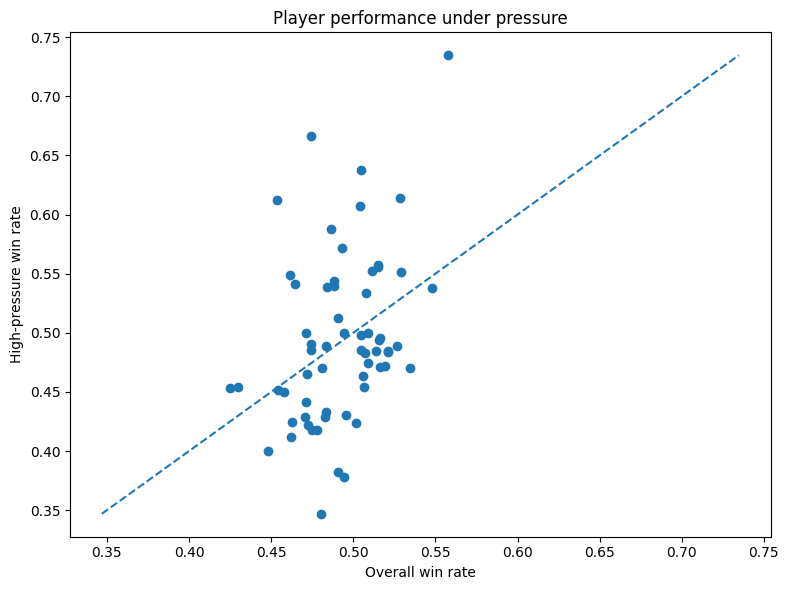

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(perf_filtered["overall_win_rate"], perf_filtered["high_pressure_win_rate"])

min_val = min(perf_filtered["overall_win_rate"].min(), perf_filtered["high_pressure_win_rate"].min())
max_val = max(perf_filtered["overall_win_rate"].max(), perf_filtered["high_pressure_win_rate"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Overall win rate")
plt.ylabel("High-pressure win rate")
plt.title("Player performance under pressure")
plt.tight_layout()
plt.savefig(OUTPUTS, dpi=300)
plt.show()